# AI-Driven Phishing Email Detection Using NLP

Project for IICT — detecting phishing emails from text and metadata using
classical ML. Pipeline: clean the raw emails, engineer text + structural
features, train a few different classifiers, and compare how they do.

Trained on the Kaggle ["Phishing Email Detection"](https://www.kaggle.com/datasets/subhajournal/phishingemails)
dataset (~18.6k emails). An earlier version of this project used a custom
synthetic dataset (see `generate_dataset.py` if curious) — this version
replaces that with real data, which changes a few things along the way
(see section 4 in particular).

Sections:
1. Load and clean the raw data
2. Clean the text
3. Quick EDA
4. Feature engineering (TF-IDF + metadata)
5. Train the models
6. Evaluate and compare
7. Simple prediction function (used later by the Streamlit app)


## Setup

In [1]:
import re
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.neural_network import MLPClassifier

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc
)
from sklearn.preprocessing import StandardScaler
from scipy.sparse import hstack, csr_matrix

# clean_text / extract_metadata live in utils.py so the app can reuse them
from utils import clean_text, extract_metadata, has_url, METADATA_COLS
# same cleaning function prepare_kaggle_data.py uses, so the notebook and
# the script that builds data/raw_emails.csv can't drift apart
from prepare_kaggle_data import clean_kaggle_data

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 1. Data

Loading the raw CSV as downloaded from Kaggle — 3 columns (an unnamed
index, `Email Text`, `Email Type`), no separate sender/subject fields, just
the raw email text and a label.


In [2]:
raw = pd.read_csv("data/Phishing_Email_raw.csv")
print(raw.shape)
raw.head()


(18650, 3)


,Unnamed: 0,Email Text,Email Type
0,0,"re : 6 . 1100 , disc : uniformitarianism , re ...",Safe Email
1,1,the other side of * galicismos * * galicismo *...,Safe Email
2,2,re : equistar deal tickets are you still avail...,Safe Email
3,3,\nHello I am your hot lil horny toy.\n I am...,Phishing Email
4,4,software at incredibly low prices ( 86 % lower...,Phishing Email


In [3]:
print(raw["Email Type"].value_counts())
print()
print("nulls in Email Text:", raw["Email Text"].isnull().sum())
print("exact duplicate rows:", raw["Email Text"].duplicated().sum())


Email Type
Safe Email        11322
Phishing Email     7328
Name: count, dtype: int64

nulls in Email Text: 16


exact duplicate rows: 1112


A few real data-quality issues to deal with before doing anything else:

- 16 rows with a null `Email Text`.
- ~1,100 exact duplicate emails — without dropping these, the same email
  could end up in both the train and test split, which would make the test
  score look better than it really is.
- A handful of rows are absurdly long (one is ~17 million characters,
  almost certainly a broken CSV row where a stray quote/comma merged several
  records together rather than one real email). Truncating everything to
  20,000 characters fixes this without losing any email that's just long
  for a normal reason — only 87 out of 18,650 rows are affected.

`clean_kaggle_data()` in `prepare_kaggle_data.py` does exactly this and is
also what actually produces `data/raw_emails.csv` for the training script,
so this cell and the real pipeline can't quietly drift apart.


In [4]:
df = clean_kaggle_data(raw.copy())
print()
print("final shape:", df.shape)
df["label"].value_counts().rename({1: "phishing", 0: "legitimate"})


dropped 16 rows with null email_text


dropped 1097 exact-duplicate rows
truncated 87 rows to 20000 characters

final shape: (17537, 2)


label
legitimate    10979
phishing       6558
Name: count, dtype: int64

Worth flagging early: this dataset's "Phishing Email" label is broader than
just modern credential-phishing. Checking how many phishing rows actually
contain a URL or urgency-style wording:


In [5]:
phish_text = df[df.label == 1]["email_text"]
print(f"phishing rows containing a URL: {phish_text.apply(has_url).mean()*100:.1f}%")
print(f"phishing rows containing urgent/verify/suspend language: "
      f"{phish_text.str.contains('urgent|verify|suspend', case=False, regex=True).mean()*100:.1f}%")


phishing rows containing a URL: 37.8%
phishing rows containing urgent/verify/suspend language: 4.2%


About a third of "phishing" emails contain a detectable URL — worth noting
this only came out right after actually checking: a naive `http\S+` pattern
misses a lot of these, because a chunk of the URLs in this dataset are
written with spaces around every slash and dot (`http : / / www . x . com`),
which `has_url()` in `utils.py` specifically accounts for. Only about 1 in
20 uses urgency language, though. Looking at a few samples makes it clear
why: this dataset is compiled from older spam/fraud corpora, so a lot of the
phishing class is generic spam (ads, scam money-transfer requests) rather
than the "click here to verify your account" style. That's a real
difference from the synthetic dataset used in an earlier version of this
project, where every phishing template was written around URLs and urgency
by design — here, URLs turn out to be a fairly strong signal after fixing
the detection, but the vocabulary itself still carries a lot of the weight,
since urgency-style phrasing is much rarer.


## 2. Cleaning the text

Same `clean_text()` as before (in `utils.py`): lowercases, strips HTML tags,
swaps URLs for a placeholder token, drops punctuation/digits, removes
stopwords using a small built-in list instead of an NLTK download.


In [6]:
df["clean_text"] = df["email_text"].apply(clean_text)
df[["email_text", "clean_text"]].head(3)


,email_text,clean_text
0,"re : 6 . 1100 , disc : uniformitarianism , re ...",re disc uniformitarianism re sex lang dick hud...
1,the other side of * galicismos * * galicismo *...,side galicismos galicismo spanish term names i...
2,re : equistar deal tickets are you still avail...,re equistar deal tickets still available assis...


In [7]:
print("empty after cleaning:", (df['clean_text'].str.strip() == '').sum())
df[["clean_text"]].sample(5, random_state=RANDOM_STATE)


empty after cleaning: 2


,clean_text
3784,available review massaro book listed linguist ...
2175,lng contracts seeking information find copies ...
9253,citizens homelink online banking investing ema...
15870,rah quoted indians poor many poor many regulat...
4201,perfect logo charset koi thinking breathing ne...


## 3. A quick look before modeling

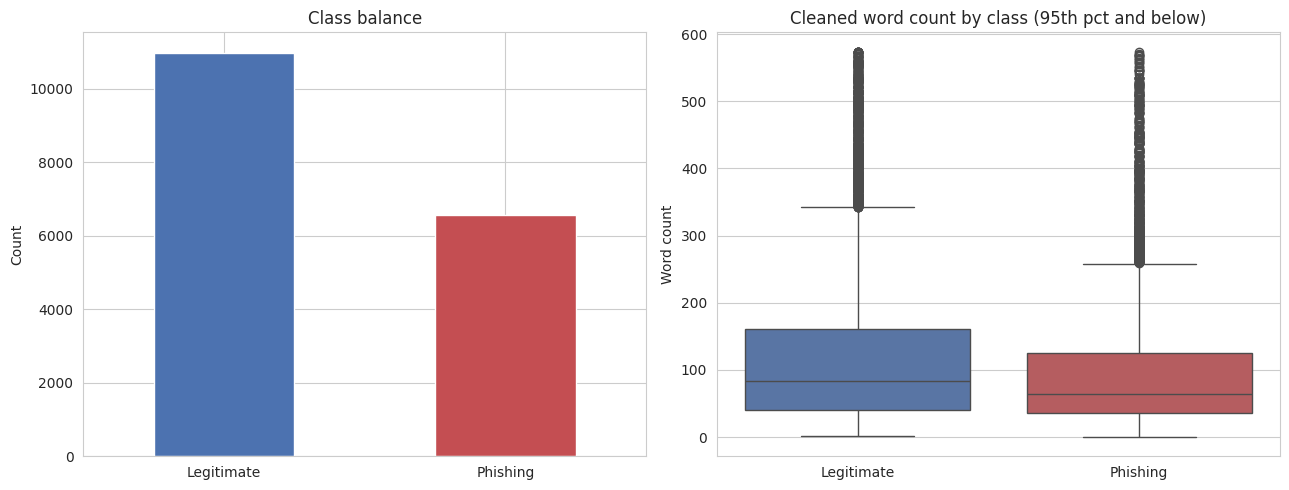

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df["label"].value_counts().rename({0: "Legitimate", 1: "Phishing"}).plot(
    kind="bar", ax=axes[0], color=["#4C72B0", "#C44E52"]
)
axes[0].set_title("Class balance")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

df["text_length"] = df["clean_text"].apply(lambda x: len(x.split()))
# a few very long emails survived truncation and squash the boxplot scale -
# clip at the 95th percentile just for this chart
cap = df["text_length"].quantile(0.95)
sns.boxplot(data=df[df.text_length <= cap], x="label", y="text_length", ax=axes[1],
            palette=["#4C72B0", "#C44E52"])
axes[1].set_xticklabels(["Legitimate", "Phishing"])
axes[1].set_title("Cleaned word count by class (95th pct and below)")
axes[1].set_xlabel("")
axes[1].set_ylabel("Word count")

plt.tight_layout()
plt.savefig("outputs/eda_overview.png", dpi=150)
plt.show()


In [9]:
from collections import Counter

def top_words(text_series, n=15):
    words = " ".join(text_series).split()
    return Counter(words).most_common(n)

print("Phishing - most common words:")
print(top_words(df[df.label == 1]["clean_text"]))
print()
print("Legitimate - most common words:")
print(top_words(df[df.label == 0]["clean_text"]))


Phishing - most common words:


[('will', 7719), ('can', 5431), ('urltoken', 5345), ('email', 4962), ('com', 4480), ('free', 4121), ('company', 3695), ('mail', 3687), ('money', 3674), ('please', 3629), ('get', 3607), ('information', 3585), ('business', 3360), ('one', 3311), ('now', 3098)]

Legitimate - most common words:


[('enron', 14034), ('will', 13355), ('ect', 10900), ('urltoken', 10426), ('can', 7885), ('com', 6003), ('university', 6001), ('one', 5869), ('please', 5865), ('language', 5852), ('new', 5413), ('hou', 5218), ('information', 4961), ('subject', 4652), ('list', 4492)]


The legitimate class leaning heavily on "enron", "ect", "hou" gives away
where that half of the dataset comes from — the Enron email corpus (a
public dataset from the Enron scandal that's widely used in email/spam
research), not general business correspondence. Worth knowing if comparing
this model's behavior against emails from a different, non-Enron source.

One more thing that only showed up after actually looking at the token list
rather than assuming clean_text() catches everything: a small number of
phishing rows contain garbled repeating character sequences (non-English —
mostly Portuguese-language spam — that got mangled by an encoding mismatch
somewhere before this dataset was assembled). `clean_text()` strips the
specific corrupted pattern now, otherwise it would show up as a meaningless
high-frequency "word".


The class imbalance here (about 63% legitimate / 37% phishing) is mild
enough that accuracy alone won't be too misleading, but precision/recall per
class still matter more than they did on the old 50/50 synthetic set.


## 4. Features: TF-IDF + metadata

Same two-group approach as before, with one change: this dataset has no
separate sender/from field, just raw email text. That means the
`suspicious_domain` feature from the earlier version (which needs a sender
address to check) can't be computed here — `METADATA_COLS` is 6 features
instead of 7:

- **TF-IDF** on the cleaned text (unigrams + bigrams). With real data
  bringing a much bigger and messier vocabulary than the templated
  synthetic set, this is bumped up to 3,000 features (was 1,500).
- **Metadata** — URL presence/count, exclamation marks, uppercase ratio,
  urgency keyword score, and email length. All computable from the text
  alone.

`suspicious_domain()` is still defined in `utils.py` and the Streamlit app
still uses it — just as a separate, informational heuristic when a user
types in a sender address, not as something the trained model has ever
seen.


In [10]:
meta_features = df["email_text"].apply(extract_metadata)
meta_df = pd.DataFrame(meta_features.tolist(), columns=METADATA_COLS)
df = pd.concat([df, meta_df], axis=1)

df.groupby("label")[METADATA_COLS].mean().rename(index={0: "Legitimate", 1: "Phishing"})


,has_url,url_count,exclamation_count,uppercase_ratio,urgency_score,email_length
label,,,,,,
Legitimate,0.415338,0.973039,0.638127,0.011157,0.198834,1848.656253
Phishing,0.378164,0.818237,3.384416,0.015331,0.567704,1641.356969


Compare this to the synthetic dataset's metadata table (in the earlier
notebook version): there, `has_url` and `suspicious_domain` were massively
different between classes because the templates were built that way. Here
`has_url` still shows a real gap between classes (consistent with the ~1-in-3
figure above), but it's much less clean-cut than the synthetic version, and
`suspicious_domain` isn't available at all for this dataset.


In [11]:
X_text, y = df["clean_text"], df["label"]

X_train_text, X_test_text, y_train, y_test, idx_train, idx_test = train_test_split(
    X_text, y, df.index, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1, 2), min_df=3, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("train:", X_train_tfidf.shape, " test:", X_test_tfidf.shape)


train: (14029, 3000)  test: (3508, 3000)


In [12]:
scaler = StandardScaler()
meta_train = scaler.fit_transform(df.loc[idx_train, METADATA_COLS].values)
meta_test = scaler.transform(df.loc[idx_test, METADATA_COLS].values)

X_train_combined = hstack([X_train_tfidf, csr_matrix(meta_train)])
X_test_combined = hstack([X_test_tfidf, csr_matrix(meta_test)])

print("combined train:", X_train_combined.shape, " combined test:", X_test_combined.shape)


combined train: (14029, 3006)  combined test: (3508, 3006)


## 5. Training the models

Same four classifiers as the brief asks for. Naive Bayes still only gets
the TF-IDF features (needs non-negative input). Fair warning: the grid
search below runs on ~14k rows x ~3k features and takes a few minutes here
— noticeably slower than it was on the 1,000-row synthetic set.


In [13]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Naive Bayes": MultinomialNB(),
    "Neural Network (MLP)": MLPClassifier(
        hidden_layer_sizes=(64, 32), max_iter=500, random_state=RANDOM_STATE, early_stopping=True
    ),
}

trained_models = {}
predictions = {}
probabilities = {}

for name, model in models.items():
    if name == "Naive Bayes":
        model.fit(X_train_tfidf, y_train)
        preds = model.predict(X_test_tfidf)
        probs = model.predict_proba(X_test_tfidf)[:, 1]
    else:
        model.fit(X_train_combined, y_train)
        preds = model.predict(X_test_combined)
        probs = model.predict_proba(X_test_combined)[:, 1]

    trained_models[name] = model
    predictions[name] = preds
    probabilities[name] = probs
    print(f"trained: {name}")


trained: Logistic Regression


trained: Random Forest
trained: Naive Bayes


trained: Neural Network (MLP)


In [14]:
# grid search on Random Forest - smaller grid than the synthetic-data version
# since each fit costs more on a dataset this size
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 30],
    "min_samples_split": [2, 5],
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    param_grid, cv=3, scoring="f1", n_jobs=-1
)
grid_search.fit(X_train_combined, y_train)

print("best params:", grid_search.best_params_)
print(f"best CV F1: {grid_search.best_score_:.4f}")

best_rf = grid_search.best_estimator_
trained_models["Random Forest"] = best_rf
predictions["Random Forest"] = best_rf.predict(X_test_combined)
probabilities["Random Forest"] = best_rf.predict_proba(X_test_combined)[:, 1]


best params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
best CV F1: 0.9590


## 6. Results

In [15]:
results = []
for name in models.keys():
    y_pred = predictions[name]
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
    })

results_df = pd.DataFrame(results).sort_values("F1-Score", ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision,Recall,F1-Score
0,Neural Network (MLP),0.981471,0.975591,0.974848,0.975219
1,Logistic Regression,0.974914,0.974419,0.958079,0.966180
2,Random Forest,0.971779,0.957046,0.967988,0.962486
3,Naive Bayes,0.957526,0.953942,0.931402,0.942538


Unlike the synthetic dataset (where all four models tied at ~99% across
every metric), there's real separation here — which makes sense, since a
harder, messier, more realistic problem gives the models more room to
actually differ. Worth checking which one comes out on top rather than
assuming it's still Random Forest by default.


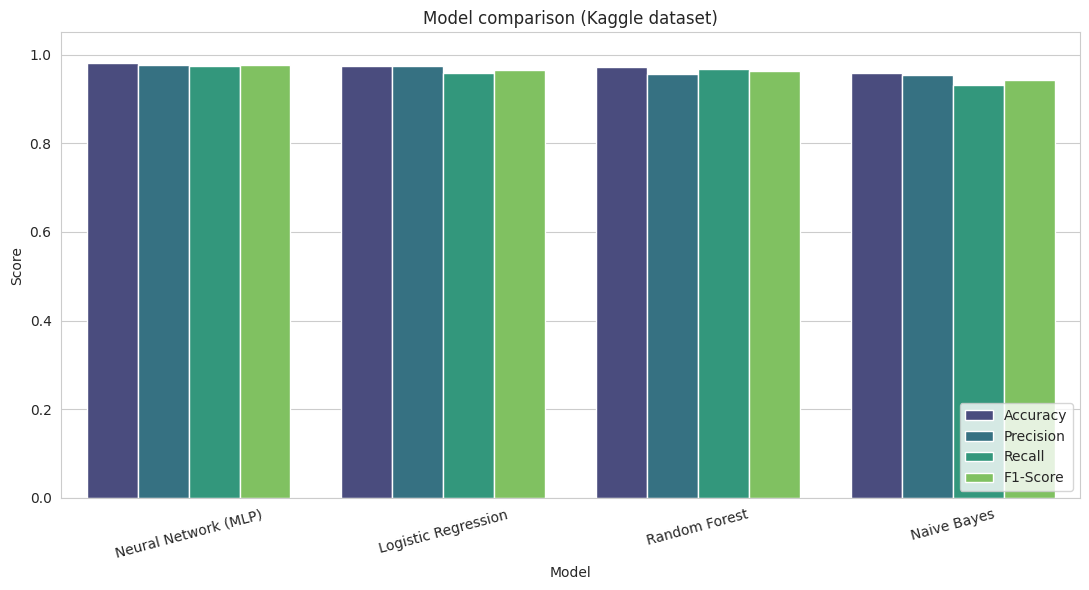

In [16]:
results_melted = results_df.melt(id_vars="Model", var_name="Metric", value_name="Score")

plt.figure(figsize=(11, 6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette="viridis")
plt.title("Model comparison (Kaggle dataset)")
plt.ylim(0, 1.05)
plt.xticks(rotation=15)
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("outputs/model_comparison.png", dpi=150)
plt.show()


In [17]:
best_model_name = results_df.iloc[0]["Model"]
print(f"best by F1: {best_model_name}\n")
print(classification_report(y_test, predictions[best_model_name], target_names=["Legitimate", "Phishing"]))


best by F1: Neural Network (MLP)

              precision    recall  f1-score   support

  Legitimate       0.98      0.99      0.99      2196
    Phishing       0.98      0.97      0.98      1312

    accuracy                           0.98      3508
   macro avg       0.98      0.98      0.98      3508
weighted avg       0.98      0.98      0.98      3508



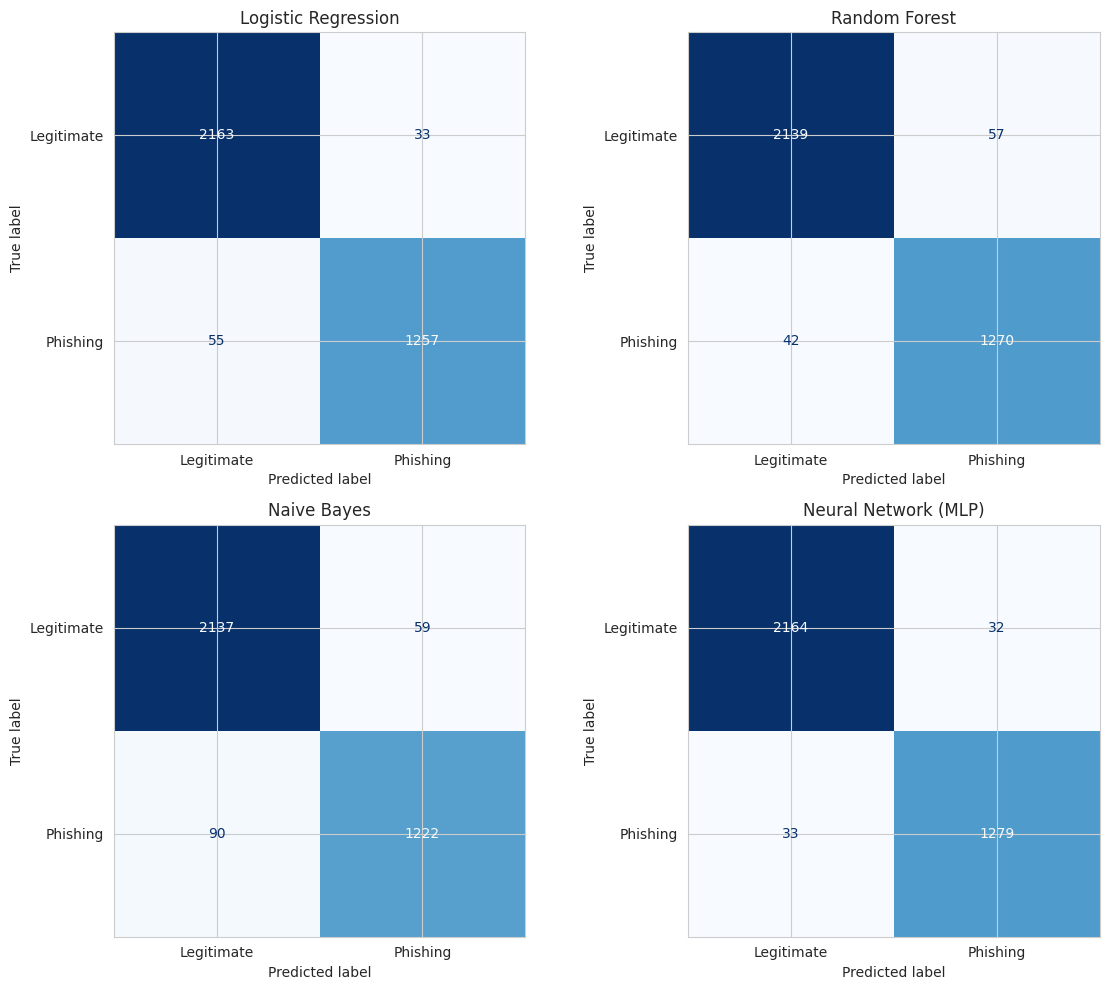

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Legitimate", "Phishing"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig("outputs/confusion_matrices.png", dpi=150)
plt.show()


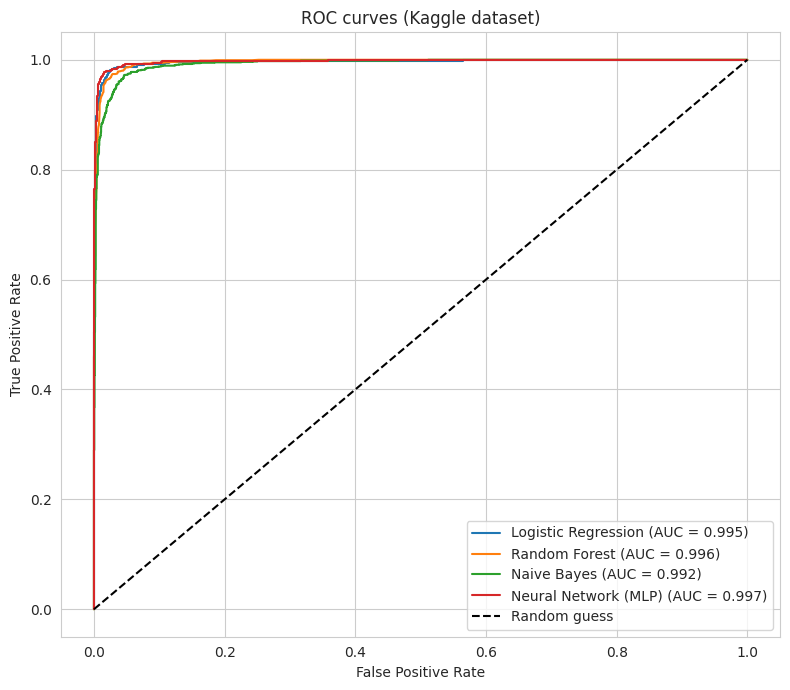

In [19]:
plt.figure(figsize=(8, 7))

for name, probs in probabilities.items():
    fpr, tpr, _ = roc_curve(y_test, probs)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves (Kaggle dataset)")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("outputs/roc_curves.png", dpi=150)
plt.show()


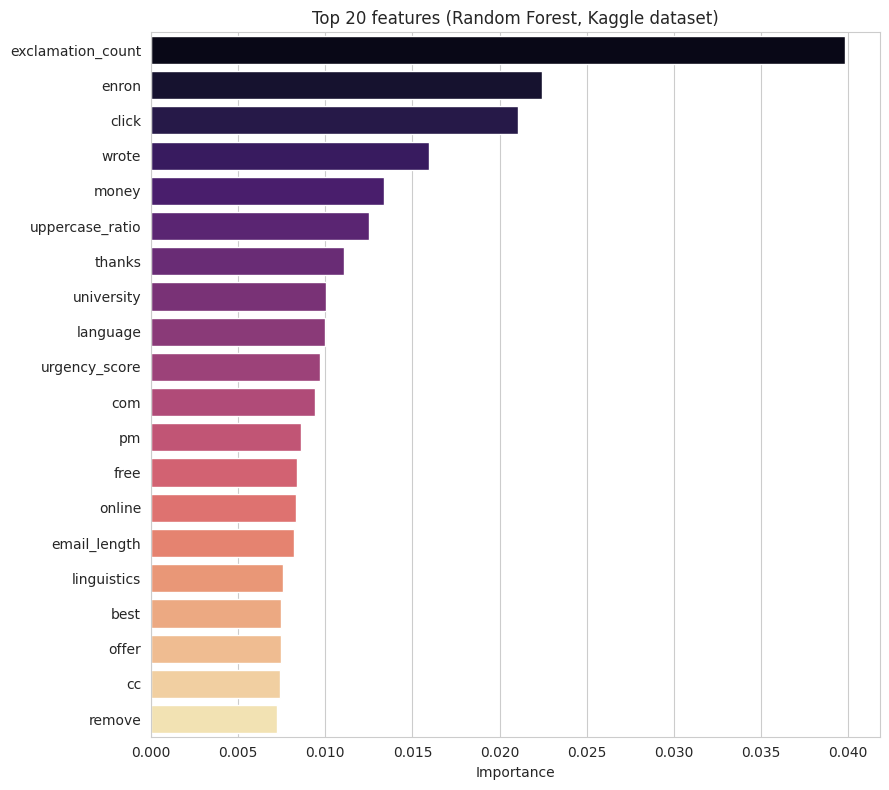

,feature,importance
3002,exclamation_count,0.039832
820,enron,0.022419
428,click,0.021028
2975,wrote,0.015950
1652,money,0.013371
3003,uppercase_ratio,0.012494
2649,thanks,0.011087
2768,university,0.010063
1391,language,0.010012
3004,urgency_score,0.009705


In [20]:
feature_names = list(tfidf.get_feature_names_out()) + METADATA_COLS
importances = trained_models["Random Forest"].feature_importances_

feat_imp_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False).head(20)

plt.figure(figsize=(9, 8))
sns.barplot(data=feat_imp_df, y="feature", x="importance", palette="magma")
plt.title("Top 20 features (Random Forest, Kaggle dataset)")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.savefig("outputs/feature_importance.png", dpi=150)
plt.show()

feat_imp_df


In [21]:
lr_model = trained_models["Logistic Regression"]
coef_df = pd.DataFrame({"feature": feature_names, "coefficient": lr_model.coef_[0]})

print("Pushes toward PHISHING:")
print(coef_df.sort_values("coefficient", ascending=False).head(10).to_string(index=False))
print()
print("Pushes toward LEGITIMATE:")
print(coef_df.sort_values("coefficient", ascending=True).head(10).to_string(index=False))


Pushes toward PHISHING:
               feature  coefficient
                 click     4.203231
                   com     3.553395
                remove     3.452733
                 money     3.047029
                  site     2.991943
                  free     2.706826
                  info     2.663788
                  life     2.634561
spamassassin sightings     2.599409
                 hello     2.582751

Pushes toward LEGITIMATE:
      feature  coefficient
        enron    -7.299960
        wrote    -5.891430
       thanks    -3.986459
     language    -3.753950
        vince    -3.432103
   university    -3.416411
urltoken date    -3.155148
     attached    -3.129491
    enron com    -3.093109
  linguistics    -3.073103


Expect a different picture here than the synthetic-data version: with URLs
and urgency language present in only a minority of phishing emails,
vocabulary-based TF-IDF features should carry more of the weight, and the
remaining metadata features (email length, exclamation marks) less. Worth
checking whether that expectation actually holds in the output above rather
than assuming it.


## 7. Prediction function

Same idea as before: one function that runs clean → TF-IDF → metadata →
combine → predict on a single new email. This is what `app.py` calls,
wired up to a Streamlit UI. Testing it on three different styles of email —
including one that's arguably out-of-distribution for this dataset (modern
brand-impersonation phishing, which this training data has relatively
little of) — is a reasonable way to sanity-check that it generalizes rather
than just memorizing training vocabulary.


In [22]:
def predict_email(subject, body, model_name="Random Forest"):
    raw_text = f"{subject} {body}"
    cleaned = clean_text(raw_text)
    tfidf_vec = tfidf.transform([cleaned])

    meta = np.array([extract_metadata(raw_text)])
    meta_scaled = scaler.transform(meta)

    model = trained_models[model_name]
    if model_name == "Naive Bayes":
        combined = tfidf_vec
    else:
        combined = hstack([tfidf_vec, csr_matrix(meta_scaled)])

    pred = model.predict(combined)[0]
    prob = model.predict_proba(combined)[0][1]
    return {"prediction": "PHISHING" if pred == 1 else "LEGITIMATE", "phishing_probability": round(float(prob), 4)}


print("modern phishing style:", predict_email(
    subject="URGENT: Your account will be suspended!",
    body="Dear customer, your account has been limited. Click here to verify immediately: "
         "http://amaz0n-verify.tk/login?id=123456 or you will lose access permanently."
))

print("legitimate business email:", predict_email(
    subject="Meeting reminder: Q3 planning at 10:00 AM",
    body="Hi, just a reminder that our meeting on Q3 planning is scheduled for 10:00 AM today. "
         "Please review the shared document beforehand."
))

print("old-school scam style (closer to this dataset's actual phishing class):", predict_email(
    subject="Urgent Business Proposal",
    body="Dear Friend, I am the son of a wealthy businessman and I need your assistance to "
         "transfer 15.5 million dollars out of my country. I will give you 30% commission for "
         "your help. Please reply with your bank details so we can proceed with this transaction."
))


modern phishing style: {'prediction': 'PHISHING', 'phishing_probability': 0.845}
legitimate business email: {'prediction': 'LEGITIMATE', 'phishing_probability': 0.125}
old-school scam style (closer to this dataset's actual phishing class): {'prediction': 'PHISHING', 'phishing_probability': 0.655}


## Summary

- Switched from the earlier synthetic dataset to the real Kaggle "Phishing
  Email Detection" dataset (~17.5k emails after cleaning). Real numbers are
  in the results table in section 6 — meaningfully lower than the synthetic
  set's ~99% across the board, and, unlike that set, the four models
  actually differ from each other here.
- This dataset's "phishing" label is broader than modern credential
  phishing — a lot of it is older-style spam and scam email. Checking this
  directly (section 1) rather than assuming it mattered, since it changes
  how much weight TF-IDF vocabulary should carry versus the structural
  metadata features that dominated on the synthetic set.
- Two real data-quality issues turned up while building the metadata
  features, both worth a mention since they'd have quietly weakened the
  model otherwise: a chunk of URLs in this dataset are written with spaces
  around the punctuation (`http : / / www . x . com`), which a plain
  `http\S+` pattern misses entirely — `has_url()` in `utils.py` handles
  this now. And a small number of non-English (mostly Portuguese) rows had
  gotten garbled by an encoding mismatch, which `clean_text()` now strips
  rather than passing through as noise tokens.
- The `suspicious_domain` feature from the earlier version couldn't be
  reused here since this dataset has no sender field — it's still available
  in `utils.py` and the app shows it as an informational heuristic, just not
  something any trained model has seen.
- The prediction-function test above checks generalization to a modern
  phishing style the training data has relatively little of — worth reading
  that result rather than assuming it either way.

**Limitations:** label quality in the raw data isn't independently verified
here — "phishing" vs "legitimate" is taken as given from the dataset. The
dataset's phishing class, being spam-heavy and somewhat dated (some samples
read as early-2000s-era spam), may not fully represent current phishing
tactics — a production system would benefit from more recent, more
narrowly-scoped phishing samples to complement this.

**Possible extensions:** pretrained embeddings (GloVe/spaCy) instead of or
alongside TF-IDF, combining this dataset with a more modern phishing-specific
one for better coverage of current tactics, and tuning the decision
threshold to favor recall on the phishing class.
